## PART A — Math Warm-Up
### Task 1: Mean Squared Error (MSE)


In [1]:
def mse(y_true, y_pred):
    """
    Compute Mean Squared Error
    """
    n = len(y_true)
    return sum((yt - yp) ** 2 for yt, yp in zip(y_true, y_pred)) / n


y_true = [2, 4, 6, 8]
y_pred = [1.5, 3.5, 6.5, 7.5]

print("MSE:", mse(y_true, y_pred))


MSE: 0.25


### Task 2: Simple Linear Function


In [2]:
# Given parameters
w = 0.5
b = 1

# Input values
x = [1, 2, 3, 4, 5]

# Linear function: y = wx + b
y_pred = [w * xi + b for xi in x]

print("Predictions:", y_pred)


Predictions: [1.5, 2.0, 2.5, 3.0, 3.5]


## PART B — Gradient Descent (Core Task)
### Task 3: Gradient Descent from Scratch


In [5]:
# Training data
x = [1, 2, 3, 4, 5]
y_true = [3, 4, 5, 6, 7]  # assume y = x + 2


In [6]:
# Initialize parameters
w = 0.0
b = 0.0

learning_rate = 0.01
epochs = 10


In [7]:
def mse(y_true, y_pred):
    total_error = 0
    for yt, yp in zip(y_true, y_pred):
        total_error += (yt - yp) ** 2
    return total_error / len(y_true)


In [8]:
n = len(x)

for epoch in range(epochs):
    y_pred = []
    
    # Forward pass
    for xi in x:
        y_pred.append(w * xi + b)
    
    # Compute loss
    loss = mse(y_true, y_pred)
    
    # Gradients
    dw = 0
    db = 0
    for xi, yt, yp in zip(x, y_true, y_pred):
        dw += -2 * xi * (yt - yp)
        db += -2 * (yt - yp)
    
    dw = dw / n
    db = db / n
    
    # Update parameters
    w = w - learning_rate * dw
    b = b - learning_rate * db
    
    # Tracking values
    print(f"Epoch {epoch+1}: Loss={loss:.4f}, w={w:.4f}, b={b:.4f}")


Epoch 1: Loss=27.0000, w=0.3400, b=0.1000
Epoch 2: Loss=15.9256, w=0.5992, b=0.1776
Epoch 3: Loss=9.4707, w=0.7967, b=0.2381
Epoch 4: Loss=5.7078, w=0.9472, b=0.2855
Epoch 5: Loss=3.5137, w=1.0616, b=0.3230
Epoch 6: Loss=2.2338, w=1.1487, b=0.3528
Epoch 7: Loss=1.4867, w=1.2148, b=0.3769
Epoch 8: Loss=1.0501, w=1.2649, b=0.3964
Epoch 9: Loss=0.7944, w=1.3029, b=0.4126
Epoch 10: Loss=0.6442, w=1.3315, b=0.4262


### Task 4: Convergence Visualization


In [9]:
loss_history = []
weight_history = []


In [10]:
for epoch in range(epochs):
    y_pred = []
    
    for xi in x:
        y_pred.append(w * xi + b)
    
    loss = mse(y_true, y_pred)
    
    dw = 0
    db = 0
    for xi, yt, yp in zip(x, y_true, y_pred):
        dw += -2 * xi * (yt - yp)
        db += -2 * (yt - yp)
    
    dw = dw / len(x)
    db = db / len(x)
    
    w = w - learning_rate * dw
    b = b - learning_rate * db

    # Track values
    loss_history.append(loss)
    weight_history.append(w)

    print(f"Epoch {epoch+1}: Loss={loss:.4f}, w={w:.4f}, b={b:.4f}")


Epoch 1: Loss=0.5554, w=1.3530, b=0.4378
Epoch 2: Loss=0.5025, w=1.3691, b=0.4478
Epoch 3: Loss=0.4704, w=1.3810, b=0.4567
Epoch 4: Loss=0.4505, w=1.3898, b=0.4647
Epoch 5: Loss=0.4378, w=1.3961, b=0.4721
Epoch 6: Loss=0.4291, w=1.4007, b=0.4788
Epoch 7: Loss=0.4229, w=1.4038, b=0.4852
Epoch 8: Loss=0.4181, w=1.4058, b=0.4913
Epoch 9: Loss=0.4142, w=1.4071, b=0.4971
Epoch 10: Loss=0.4108, w=1.4077, b=0.5028


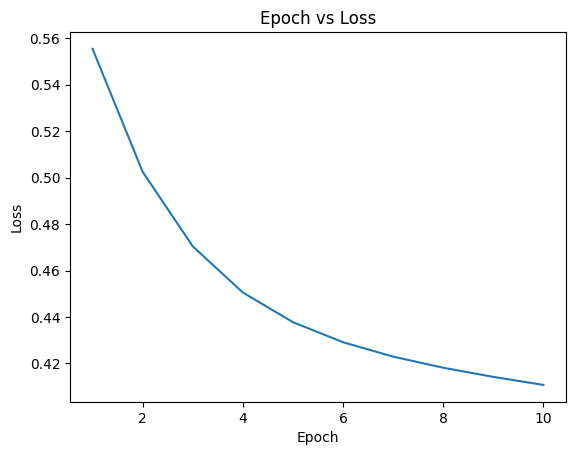

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(range(1, epochs + 1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs Loss")
plt.show()


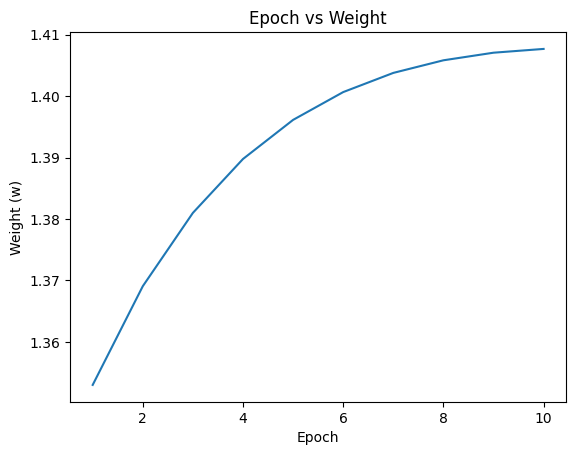

In [12]:
plt.figure()
plt.plot(range(1, epochs + 1), weight_history)
plt.xlabel("Epoch")
plt.ylabel("Weight (w)")
plt.title("Epoch vs Weight")
plt.show()


## PART C — Comparison (Reality Check)
### Task 5: Compare with sklearn LinearRegression


In [13]:
import numpy as np

X = np.array(x).reshape(-1, 1)
y = np.array(y_true)


In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

sklearn_w = model.coef_[0]
sklearn_b = model.intercept_

print("Sklearn Weight (w):", sklearn_w)
print("Sklearn Bias (b):", sklearn_b)


Sklearn Weight (w): 1.0
Sklearn Bias (b): 2.0


In [15]:
y_pred_sklearn = model.predict(X)

sklearn_loss = mse(y_true, y_pred_sklearn)
print("Sklearn MSE Loss:", sklearn_loss)


Sklearn MSE Loss: 0.0


### Comparison Results

| Parameter        | Gradient Descent | Sklearn |
|------------------|------------------|---------|
| Weight (w)       | (from last epoch) | (printed above) |
| Bias (b)         | (from last epoch) | (printed above) |
| Final Loss (MSE) | (last loss value) | (printed above) |


### Observation

The values obtained using gradient descent and sklearn are slightly different because:

- Gradient descent uses an iterative optimization process
- Sklearn uses an analytical solution for linear regression
- Limited epochs and learning rate can prevent exact convergence
- Numerical precision differences also affect results
